In [ ]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Set, Dict, Any
from pathlib import Path

# Constants
# Notebook lives at .../analysis/notebooks; two parent steps reach the repository root.

REPO_ROOT = Path.cwd().parent.parent
PROJECT_ROOT = REPO_ROOT / "archive" / "References" / "LLM-Needs-a-Plan-main" / "LLM-Needs-a-Plan-main"
RESULTS_DIR = os.path.join(PROJECT_ROOT, "src/results")
DATA_DIR = os.path.join(PROJECT_ROOT, "src/data")

print(f"Project Root: {PROJECT_ROOT}")
print(f"Results Dir: {RESULTS_DIR}")
print(f"Data Dir: {DATA_DIR}")

Project Root: C:/Users/utente/OneDrive/Documenti/GitHub/LLM_Benchmark/archive/References/LLM-Needs-a-Plan-main/LLM-Needs-a-Plan-main
Results Dir: C:/Users/utente/OneDrive/Documenti/GitHub/LLM_Benchmark/archive/References/LLM-Needs-a-Plan-main/LLM-Needs-a-Plan-main\src/results
Data Dir: C:/Users/utente/OneDrive/Documenti/GitHub/LLM_Benchmark/archive/References/LLM-Needs-a-Plan-main/LLM-Needs-a-Plan-main\src/data


In [ ]:
def parse_result_file(file_path: str) -> Dict[str, Any]:
    """
    Parse the result file to extract the plan actions and metadata.
    """
    actions = []
    metadata = {}
    
    try:
        with open(file_path, 'r') as f:
            content = f.read()
            
        # Split content and metadata if separator exists
        parts = content.split("--- Processing Metadata ---")
        plan_content = parts[0]
        metadata_content = parts[1] if len(parts) > 1 else ""
        
        # Parse Metadata
        if metadata_content:
            for line in metadata_content.strip().split('\n'):
                if ':' in line:
                    key, value = line.split(':', 1)
                    metadata[key.strip()] = value.strip()
                    
        # Parse Actions from plan_content
        lines = plan_content.strip().split('\n')
        for line in lines:
            line = line.strip()
            if not line:
                continue
            # Check if line looks like (action ...)
            if line.startswith('(') and line.endswith(')'):
                actions.append(line)
                        
    except Exception as e:
        print(f"Error parsing {file_path}: {e}")
        
    return {
        "actions": actions,
        "metadata": metadata
    }

In [ ]:
# Main processing loop
results_data = []

# Iterate over models
for model in os.listdir(RESULTS_DIR):
    model_path = os.path.join(RESULTS_DIR, model)
    if not os.path.isdir(model_path):
        continue
        
    print(f"Processing model: {model}")
    
    # Iterate over domains
    for domain in os.listdir(model_path):
        domain_results_path = os.path.join(model_path, domain)
        if not os.path.isdir(domain_results_path):
            continue
            
        print(f"  Processing domain: {domain}")
        
        # Iterate over plans
        for plan_file in os.listdir(domain_results_path):
            if not plan_file.endswith("_plan.txt"):
                continue
                
            # Extract instance name (e.g., instance-01)
            instance_name = plan_file.replace("_plan.txt", "")
            plan_path = os.path.join(domain_results_path, plan_file)
            
            # Parse file
            parsed = parse_result_file(plan_path)
            actions = parsed["actions"]
            metadata = parsed["metadata"]
            
            # Extract validity from metadata
            is_valid_str = metadata.get("Plan Valid", "False")
            is_valid = is_valid_str.lower() == "true"
            
            results_data.append({
                "Model": model,
                "Domain": domain,
                "Problem": instance_name,
                "Valid": is_valid,
                "Length": len(actions),
                "Iterations": metadata.get("Iterations", "N/A"),
                "Chain_of_Thought": metadata.get("Chain of Thought", "N/A")
            })

print("Processing complete.")

Processing model: gemma3
  Processing domain: citycar
  Processing domain: tetris
Processing model: kimi
  Processing domain: citycar
  Processing domain: tetris
Processing model: llama3
  Processing domain: citycar
  Processing domain: tetris
Processing model: phi4
  Processing domain: citycar
  Processing domain: tetris
Processing complete.


In [ ]:
# Create DataFrame
df = pd.DataFrame(results_data)
print(f"Total records: {len(df)}")
df.head()

Total records: 160


,Model,Domain,Problem,Valid,Length,Iterations,Chain_of_Thought
0,gemma3,citycar,instance-01,True,52,2,True
1,gemma3,citycar,instance-02,True,657,2,True
2,gemma3,citycar,instance-03,False,18,4,True
3,gemma3,citycar,instance-04,False,78,4,True
4,gemma3,citycar,instance-05,False,26,4,True


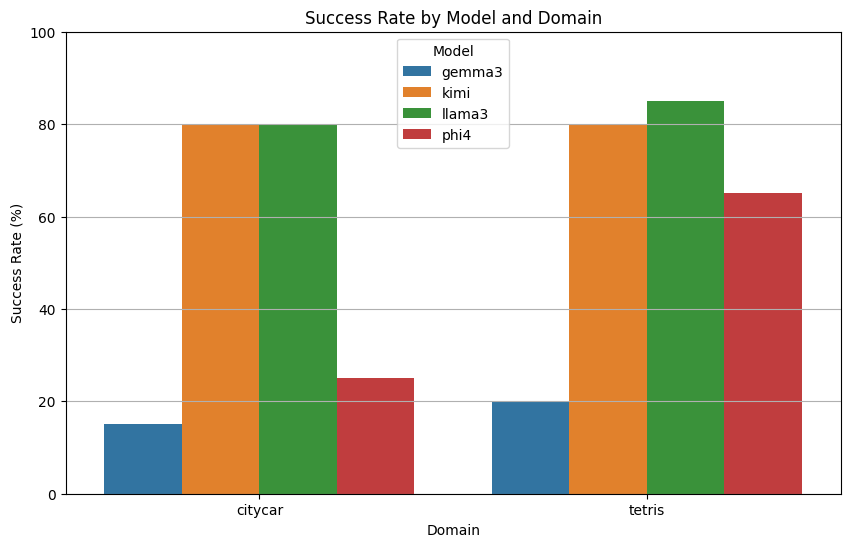

    Model   Domain  Valid  Success Rate (%)
0  gemma3  citycar   0.15              15.0
1  gemma3   tetris   0.20              20.0
2    kimi  citycar   0.80              80.0
3    kimi   tetris   0.80              80.0
4  llama3  citycar   0.80              80.0
5  llama3   tetris   0.85              85.0
6    phi4  citycar   0.25              25.0
7    phi4   tetris   0.65              65.0


In [ ]:
# Analysis: Success Rate
if not df.empty:
    success_rates = df.groupby(['Model', 'Domain'])['Valid'].mean().reset_index()
    success_rates['Success Rate (%)'] = success_rates['Valid'] * 100
    
    plt.figure(figsize=(10, 6))
    sns.barplot(data=success_rates, x='Domain', y='Success Rate (%)', hue='Model')
    plt.title('Success Rate by Model and Domain')
    plt.ylim(0, 100)
    plt.grid(axis='y')
    plt.show()
    
    print(success_rates)
else:
    print("No data to plot.")

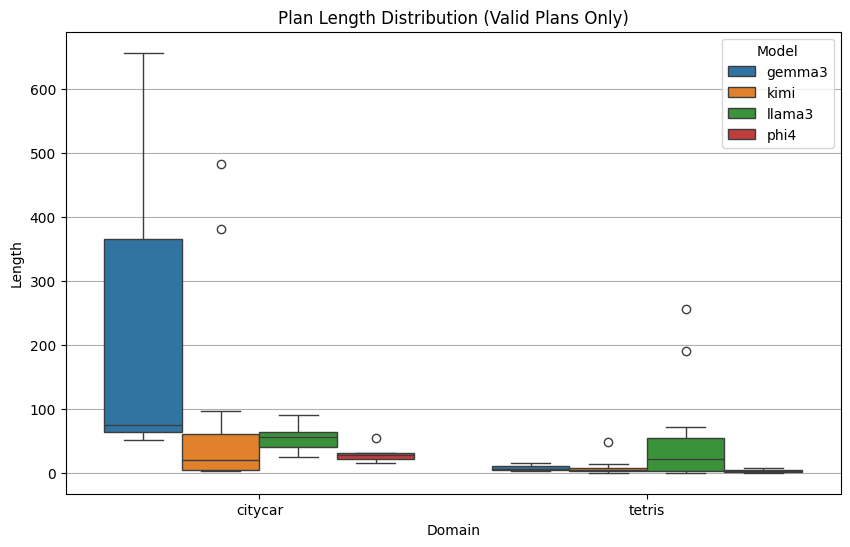

In [ ]:
# Analysis: Plan Length (only for valid plans)
if not df.empty:
    valid_plans = df[df['Valid'] == True]
    
    if not valid_plans.empty:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=valid_plans, x='Domain', y='Length', hue='Model')
        plt.title('Plan Length Distribution (Valid Plans Only)')
        plt.grid(axis='y')
        plt.show()
    else:
        print("No valid plans to analyze length.")
else:
    print("No data to plot.")

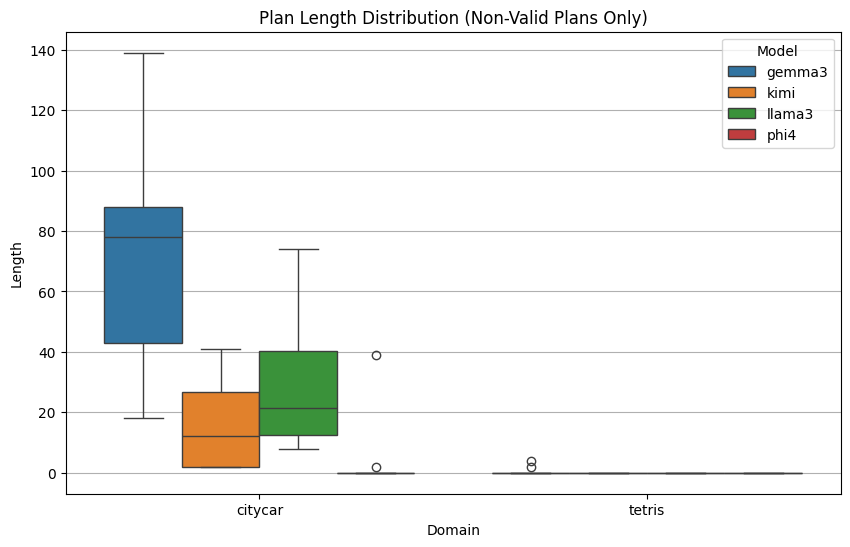

In [ ]:
# Analysis: Plan Length (only for valid plans)
if not df.empty:
    valid_plans = df[df['Valid'] == False]
    
    if not valid_plans.empty:
        plt.figure(figsize=(10, 6))
        sns.boxplot(data=valid_plans, x='Domain', y='Length', hue='Model')
        plt.title('Plan Length Distribution (Non-Valid Plans Only)')
        plt.grid(axis='y')
        plt.show()
    else:
        print("No valid plans to analyze length.")
else:
    print("No data to plot.")

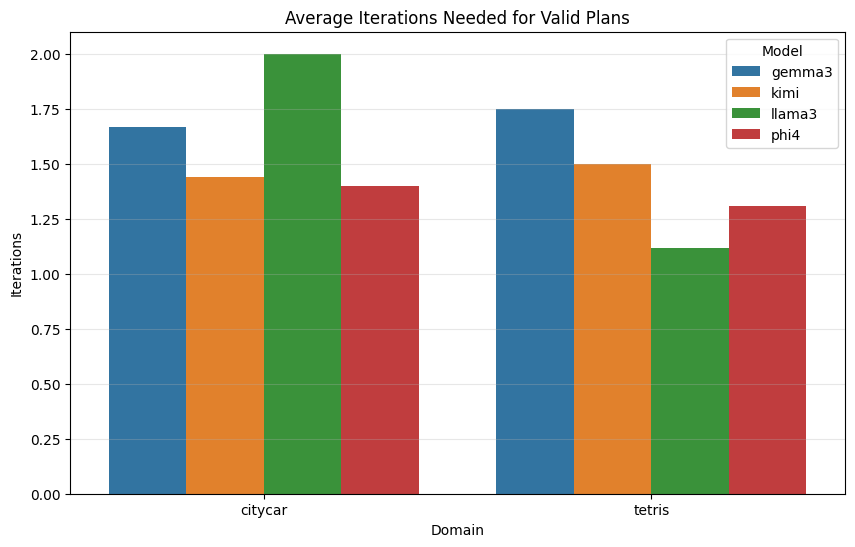

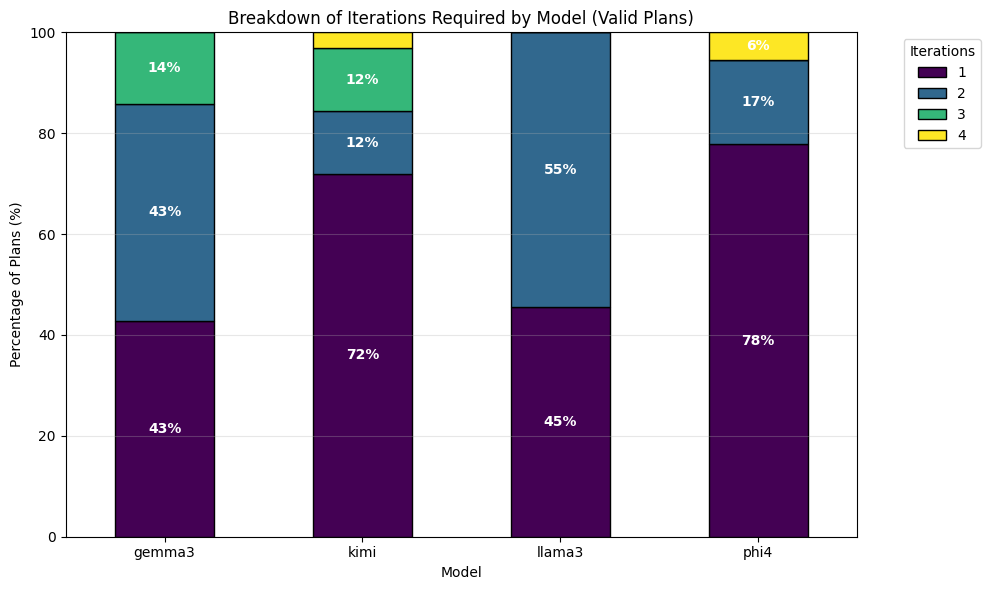

In [ ]:
# Analysis: Iterations needed for Valid Plans
if not df.empty:
    # Ensure Iterations is numeric
    df['Iterations'] = pd.to_numeric(df['Iterations'], errors='coerce')
    
    valid_plans_iter = df[df['Valid'] == True].dropna(subset=['Iterations'])
    
    if not valid_plans_iter.empty:
        # Strategy 1: Average Iterations (Bar Chart)
        # A simple bar chart showing the average number of iterations per model/domain
        avg_iter = valid_plans_iter.groupby(['Domain', 'Model'])['Iterations'].mean().reset_index()
        
        plt.figure(figsize=(10, 6))
        sns.barplot(data=avg_iter, x='Domain', y='Iterations', hue='Model')
        plt.title('Average Iterations Needed for Valid Plans')
        plt.grid(axis='y', alpha=0.3)
        plt.show()
        
        # Strategy 2: Stacked Bar Chart (Percentage)
        # Shows the proportion of plans solved in N iterations for each model
        ct_model = pd.crosstab(valid_plans_iter['Model'], valid_plans_iter['Iterations'], normalize='index') * 100
        
        ax = ct_model.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis', edgecolor='black')
        plt.title('Breakdown of Iterations Required by Model (Valid Plans)')
        plt.ylabel('Percentage of Plans (%)')
        plt.xlabel('Model')
        plt.legend(title='Iterations', bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.grid(axis='y', alpha=0.3)
        plt.xticks(rotation=0)
        
        # Add percentage labels
        for c in ax.containers:
            # Only label if segment is big enough
            labels = [f'{v.get_height():.0f}%' if v.get_height() > 5 else '' for v in c]
            ax.bar_label(c, labels=labels, label_type='center', color='white', fontsize=10, weight='bold')
            
        plt.tight_layout()
        plt.show()
        
    else:
        print("No valid plans with iteration data to analyze.")
else:
    print("No data to plot.")

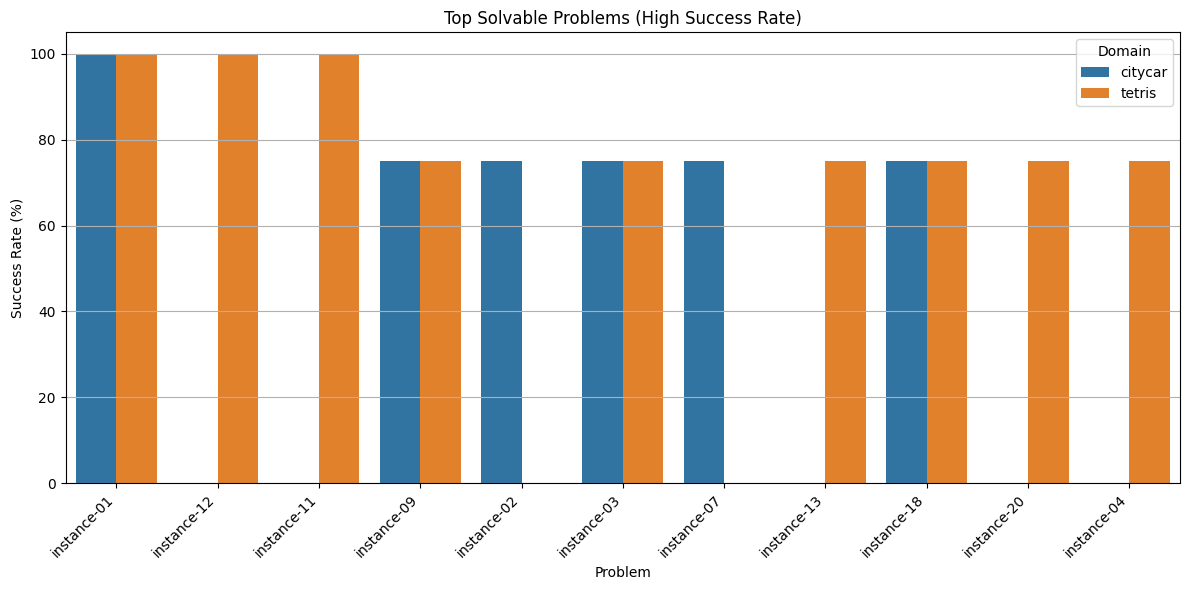

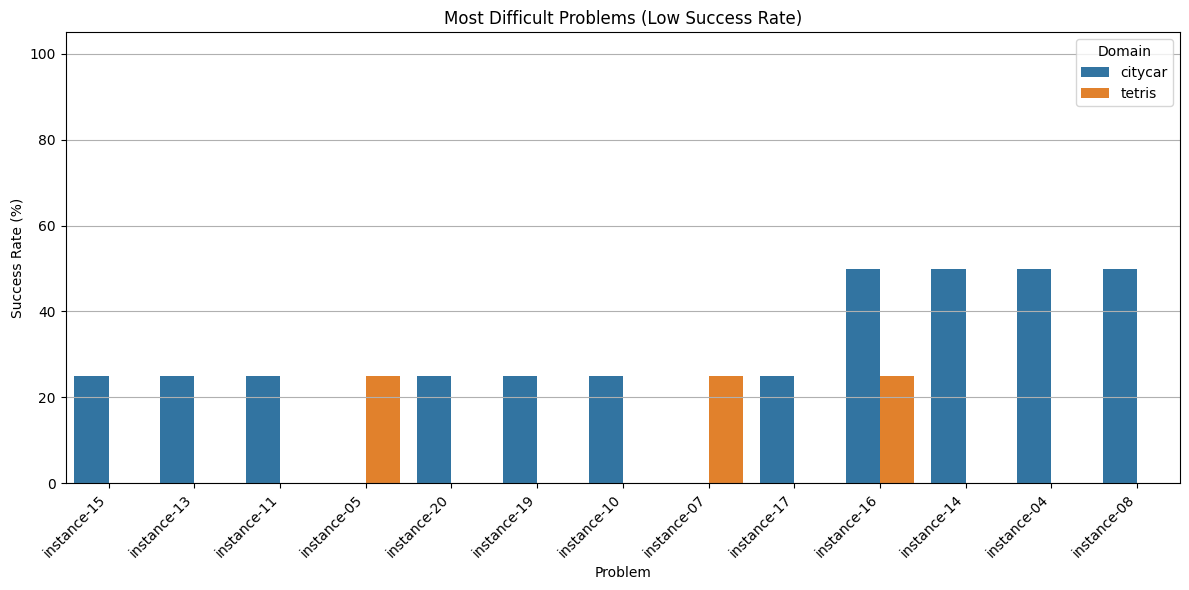

Top 5 Solvable Problems:
     Domain      Problem  Success Rate (%)
0   citycar  instance-01             100.0
31   tetris  instance-12             100.0
30   tetris  instance-11             100.0
20   tetris  instance-01             100.0
8   citycar  instance-09              75.0

Top 5 Difficult Problems:
     Domain      Problem  Success Rate (%)
34   tetris  instance-15               0.0
12  citycar  instance-13              25.0
10  citycar  instance-11              25.0
14  citycar  instance-15              25.0
24   tetris  instance-05              25.0


In [ ]:
# Analysis: Problem Solvability Classification
if not df.empty:
    # Calculate success rate per problem across all models
    # We group by Domain and Problem to handle same problem names in different domains if any
    problem_stats = df.groupby(['Domain', 'Problem'])['Valid'].mean().reset_index()
    problem_stats['Success Rate (%)'] = problem_stats['Valid'] * 100

    # Build a fixed palette per domain (consistent across plots)
    # Force order: citycar first, then tetris, then any others (if present)
    desired_order = ["citycar", "tetris"]
    other_domains = [d for d in sorted(df['Domain'].unique()) if d not in desired_order]
    domains = desired_order + other_domains

    base_colors = sns.color_palette("tab10", n_colors=len(domains))
    domain_palette = {d: c for d, c in zip(domains, base_colors)}

    # Ensure Domain is a categorical with the desired order (affects legend order)
    problem_stats['Domain'] = pd.Categorical(problem_stats['Domain'],
                                             categories=domains,
                                             ordered=True)
    
    # 1. Most Solvable Problems (Top 15)
    top_solvable = problem_stats.sort_values('Success Rate (%)', ascending=False).head(15)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=top_solvable,
        x='Problem',
        y='Success Rate (%)',
        hue='Domain',
        hue_order=domains,
        palette=domain_palette
    )
    plt.title('Top Solvable Problems (High Success Rate)')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 105)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
    
    # 2. Most Unsolvable Problems (Bottom 15)
    # We look for 0% or low success rate
    bottom_unsolvable = problem_stats.sort_values('Success Rate (%)', ascending=True).head(15)
    
    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=bottom_unsolvable,
        x='Problem',
        y='Success Rate (%)',
        hue='Domain',
        hue_order=domains,
        palette=domain_palette
    )
    plt.title('Most Difficult Problems (Low Success Rate)')
    plt.xticks(rotation=45, ha='right')
    plt.ylim(0, 105)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()
    
    # Display tables
    print("Top 5 Solvable Problems:")
    print(top_solvable[['Domain', 'Problem', 'Success Rate (%)']].head(5))
    print("\nTop 5 Difficult Problems:")
    print(bottom_unsolvable[['Domain', 'Problem', 'Success Rate (%)']].head(5))
else:
    print("No data to plot.")